
##Argimiro Arratia @2025 Computational Finance
##PyLab: Financial Time series forecasting with Gaussian Process:
## Goal: to forecast  PRICE or RETURN of S&P500 index with information set (features) lagged values of target + Price-to-Earning index and lags
###### Testing Shiller&Campbell hyp: PE10 --> S&P500
###### http://computationalfinance.lsi.upc.edu


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn import gaussian_process
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn import metrics

<Axes: xlabel='Date'>

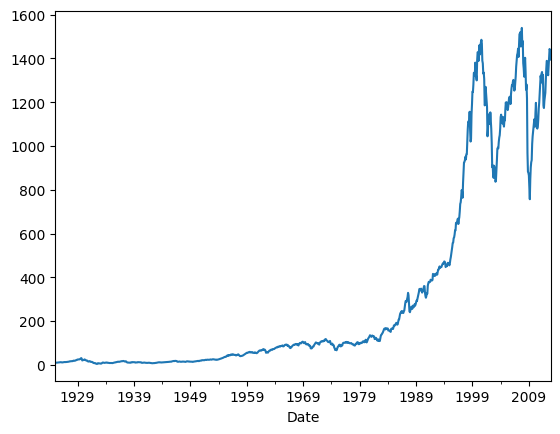

In [44]:
# Read data
sp500 = pd.read_csv('SP500_shiller.csv', index_col=0, parse_dates=True)
# Select data from 1925 to 2012
data = sp500.loc['1925-01-01':'2012-12-31']
data['SP500'].plot()

In [3]:
data.head()

,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,P/E10
Date,,,,,,,,,
1925-01-01,10.58,0.55,0.96,17.3,3.86,143.53,7.52,12.98,9.69
1925-02-01,10.67,0.56,0.98,17.2,3.85,145.59,7.62,13.42,9.83
1925-03-01,10.39,0.56,1.01,17.3,3.83,140.95,7.63,13.70,9.52
1925-04-01,10.28,0.57,1.04,17.2,3.81,140.27,7.73,14.15,9.48
1925-05-01,10.61,0.57,1.06,17.3,3.80,143.94,7.74,14.42,9.73


In [45]:
# Frequency of sampling
tau = 1 #data is monthly. Try tau=12 (year), tau=3 (quarterly)

In [46]:
# Option 1. Target and Feature as plain Price
target = data['SP500']
sp500PE = data['P/E10'].dropna() ##feature:P/E MA(10)
sp500PE.head()

,P/E10
Date,
1925-01-01,9.69
1925-02-01,9.83
1925-03-01,9.52
1925-04-01,9.48
1925-05-01,9.73


In [47]:
# Option 2. Target and Feature as Returns
sp500PE = np.log(sp500PE).diff(tau)
target = np.log(target).diff(tau)
# try non-center (above) /center target (below)
target = target - target.mean() ##Center the target

In [48]:
# Model Inputs:
# Define matrix of features (each column is a feature)
# Features: lags 1,2,3 with (or w/o) PE10 and lags 1,2
feat = pd.concat([target.shift(1), target.shift(2), target.shift(3),
                   sp500PE.shift(1), sp500PE.shift(2),
                  # add other features here,
                  target], axis=1)
feat.columns = ['lag.1', 'lag.2', 'lag.3',
                 'PE10.1', 'PE10.2',
                # names of other features,
                'TARGET']
feat = feat.dropna()
feat.head()

,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1925-05-01,-0.015289,-0.031238,0.003825,-0.004211,-0.032044,0.026951
1925-06-01,0.026951,-0.015289,-0.031238,0.026030,-0.004211,0.013104
1925-07-01,0.013104,0.026951,-0.015289,0.007168,0.026030,0.022753
1925-08-01,0.022753,0.013104,0.026951,0.016195,0.007168,0.008777
1925-09-01,0.008777,0.022753,0.013104,0.014948,0.016195,0.018203


In [49]:
# Divide data into training (75%) and testing (25%).
T = len(feat)
p = 0.75
trainindex = round(p*T)

# process class sets as data frames
training = feat.iloc[:trainindex, :]
testing = feat.iloc[trainindex:, :]

display(training.tail())
display(testing.head())

,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1990-09-01,-0.089470,-0.005645,0.023894,-0.093228,-0.003936,-0.052135
1990-10-01,-0.052135,-0.089470,-0.005645,-0.055305,-0.093228,-0.031280
1990-11-01,-0.031280,-0.052135,-0.089470,-0.031875,-0.055305,0.021609
1990-12-01,0.021609,-0.031280,-0.052135,0.024660,-0.031875,0.037159
1991-01-01,0.037159,0.021609,-0.031280,0.042532,0.024660,-0.014611


,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1991-02-01,-0.014611,0.037159,0.021609,-0.015258,0.042532,0.102385
1991-03-01,0.102385,-0.014611,0.037159,0.105681,-0.015258,0.022639
1991-04-01,0.022639,0.102385,-0.014611,0.026729,0.105681,0.015037
1991-05-01,0.015037,0.022639,0.102385,0.018900,0.026729,-0.009107
1991-06-01,-0.009107,0.015037,0.022639,-0.006630,0.018900,-0.003852


In [12]:
# GP Kernel: vanilla is non-stationary; tanh, rbf are stationary
# Define my own Kernel (for vectors).
# SE kernel with length scale l
l = 0.003  # 0.15, 0.3

MyKer = C(1.5, (1e-3, 1e3)) * RBF(l, (1e-2, 1e2))


In [24]:
# Import the Matern kernel
from sklearn.gaussian_process.kernels import Matern

MyKer = Matern()

In [51]:
# Define the Gaussian Process Regressor
gpfit = gaussian_process.GaussianProcessRegressor(
    kernel=RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)), #MyKer
    alpha=0.003,  # the initial noise variance: 0.001 default min value
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=0,
)


In [52]:
training

,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1925-05-01,-0.015289,-0.031238,0.003825,-0.004211,-0.032044,0.026951
1925-06-01,0.026951,-0.015289,-0.031238,0.026030,-0.004211,0.013104
1925-07-01,0.013104,0.026951,-0.015289,0.007168,0.026030,0.022753
1925-08-01,0.022753,0.013104,0.026951,0.016195,0.007168,0.008777
1925-09-01,0.008777,0.022753,0.013104,0.014948,0.016195,0.018203
...,...,...,...,...,...,...
1990-09-01,-0.089470,-0.005645,0.023894,-0.093228,-0.003936,-0.052135
1990-10-01,-0.052135,-0.089470,-0.005645,-0.055305,-0.093228,-0.031280
1990-11-01,-0.031280,-0.052135,-0.089470,-0.031875,-0.055305,0.021609


In [53]:
# Select the features to be used in the GP
# X = training[['lag.1', 'lag.2', 'lag.3', 'PE10.1', 'PE10.2']]
X = training[['lag.1', 'lag.2', 'lag.3', 'PE10.1', 'PE10.2']]
# Select the target
y = training['TARGET']
# Fit the model
gpfit.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=0.003, kernel=RBF(length_scale=1),
                         n_restarts_optimizer=10, normalize_y=True,
                         random_state=0)

In [54]:
# select all columns except the target
Xtest = testing[['lag.1', 'lag.2', 'lag.3', 'PE10.1', 'PE10.2']]
# build predictor (predict on test data)
GPpredict = gpfit.predict(Xtest)

In [55]:
# Evaluation of Results
df_res = pd.DataFrame({'true': testing['TARGET'], 'pred': GPpredict})
df_res

,true,pred
Date,,
1991-02-01,0.102385,-0.005995
1991-03-01,0.022639,-0.000243
1991-04-01,0.015037,-0.000606
1991-05-01,-0.009107,0.000852
1991-06-01,-0.003852,-0.004897
...,...,...
2012-08-01,0.026965,-0.040420
2012-09-01,0.023436,-0.028798
2012-10-01,-0.008533,0.031188


In [56]:
res = metrics.r2_score(df_res['true'], df_res['pred'])
print('R2 = ', res)

R2 =  -0.5382249228777192


In [57]:
# Check the gap between training error (mse) and testing error
# (mse) to see if the model is overfitting
# Training error
yhat = gpfit.predict(X)
res = metrics.r2_score(y, yhat)
print('R2 = ', res)

R2 =  0.9997714731323507


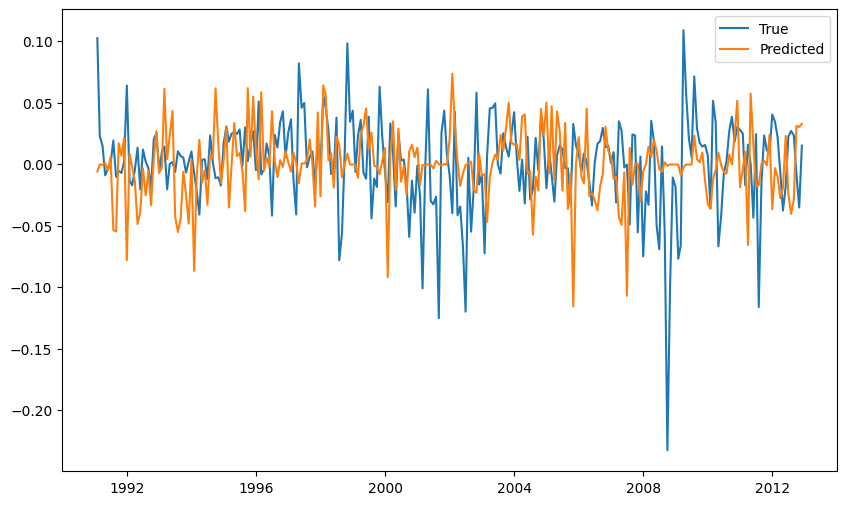

In [58]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(df_res['true'], label='True')
plt.plot(df_res['pred'], label='Predicted')
plt.legend()
plt.show()

In [59]:
# Compute the gap between training error and testing error
train_error = metrics.mean_squared_error(y, yhat)
testing_error = metrics.mean_squared_error(df_res['true'], df_res['pred'])
gap = testing_error - train_error
gap

0.0021529644205269933